<a href="https://colab.research.google.com/github/pokechiu827/CSC2053MyCode/blob/main/HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW5 - Lunar Lander Reinforcement Learning

For this homework we will be applying reinforcement learning to the lunar lander environment.

In [1]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.3 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.animation
import matplotlib.pyplot as plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')
import gymnasium as gym

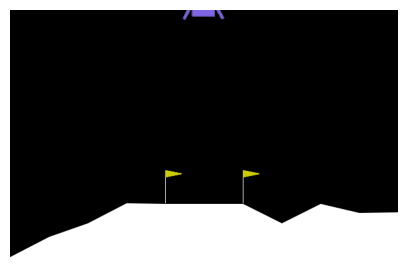

In [3]:
env = gym.make('LunarLander-v3', render_mode="rgb_array")
obs, info = env.reset()

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

In [4]:
print("Lander coordinates: ", obs[0], obs[1])
print("Lander velocities: ", obs[2], obs[3])
print("Lander angle: ", obs[4])
print("Lander angular velocity: ", obs[5])
print("Legs touching ground?: ", obs[6], obs[7])

Lander coordinates:  -0.0034217834 1.4013578
Lander velocities:  -0.34660393 -0.42499834
Lander angle:  0.0039717746
Lander angular velocity:  0.07851093
Legs touching ground?:  0.0 0.0


### Action Space:

0. do nothing
1. fire left engine
2. fire main engine
3. fire right engine

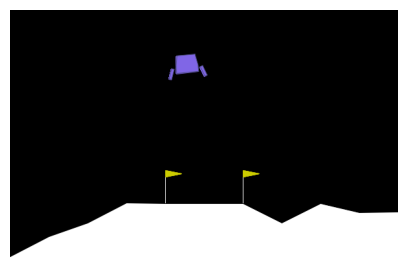

Lander coordinates:  -0.08901167 0.96789324
Lander velocities:  -0.34626126 -1.0916966
Lander angle:  0.10074975
Lander angular velocity:  0.07729707
Legs touching ground?:  0.0 0.0
Reward:  -0.5964315121536572


In [5]:
for x in range(25):
    obs, reward, done, truncated, info = env.step(0)
plot_environment(env)
plt.show()
print("Lander coordinates: ", obs[0], obs[1])
print("Lander velocities: ", obs[2], obs[3])
print("Lander angle: ", obs[4])
print("Lander angular velocity: ", obs[5])
print("Legs touching ground?: ", obs[6], obs[7])
print("Reward: ", reward)

### Write a better basic_policy than the one below.  

Rewards are given for:
1. Distance to landing pad (closer is better)
2. Speed of lander (slower is better)
3. Penalty for how far the lander is tilted
4. +10 pts for each leg touching ground
5. -0.03 pts for each step in which a side engine is firing
6. -0.3 pts for each step in which the main engine is firing
7. -100 for crashing
8. +100 for landing safely

Full credit is given for a basic policy which achieves a mean total > 0.  Partial credit given for basic policies which achieve mean scores below 0.

In [6]:
def basic_policy(obs):
    x, y, vx, vy, ang, angV, lleg, rleg = obs
    # Write some rules here to achieve better performance for your lander

    # Angle Stabilization
    if ang > 0.05:  # Tilted left
        return 3   # Fire right engine
    elif ang < -0.05: # Tilted right
        return 1     # Fire left engine

    # Control Altitude and Speed when Stable
    if vy < -0.3 and y > -0.3:
        return 2   # Fire main engine

    # Horizontal Speed
    if x > 0.5 and vx > 0.5: # Too far right, move left
        return 1
    if x < -0.5 and vx < -0.5: # Too far left, move right
        return 3

    # Default: Do nothing (0)
    return 0


totals = []
for episode in range(100):
    episode_rewards = 0
    obs, info = env.reset(seed=episode)
    for step in range(200):
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        episode_rewards += reward
        if done or truncated:
            break

    totals.append(episode_rewards)

print("Mean total score: ", np.mean(totals))

def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = matplotlib.animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

def show_one_episode(policy, n_max_steps=200):
    frames = []
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, info = env.reset()
    score = 0
    for step in range(n_max_steps):
        frames.append(env.render())
        action = policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        score += reward
        if done or truncated:
            break
    env.close()
    return plot_animation(frames)

show_one_episode(basic_policy)

Mean total score:  -35.33253513659902


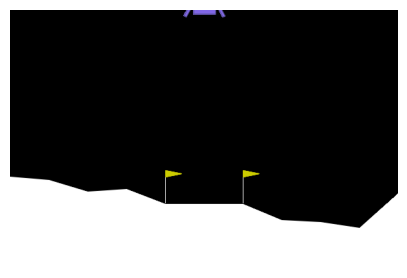

[ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]


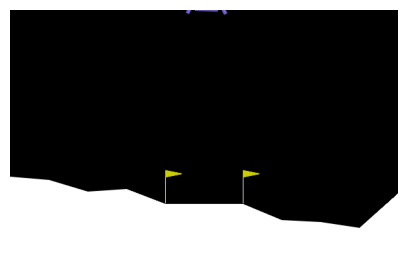

[ 0.01378269  1.4452963   0.23236378  0.18812372 -0.01566659 -0.05203186
  0.          0.        ]


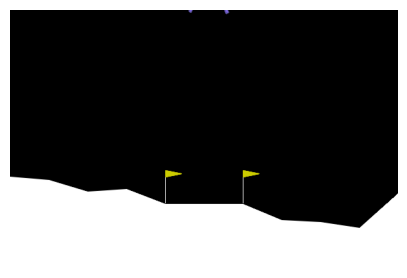

[ 0.02527037  1.4574637   0.23240192  0.05477936 -0.02866724 -0.05199131
  0.          0.        ]


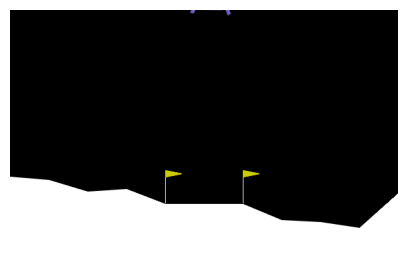

[ 0.03676004  1.4546326   0.23243935 -0.0785665  -0.04165786 -0.05195153
  0.          0.        ]


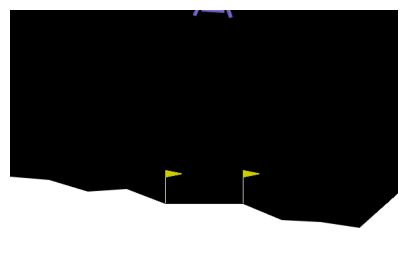

[ 0.04818411  1.4368126   0.22398193 -0.21139754 -0.05292902 -0.01771604
  0.          0.        ]


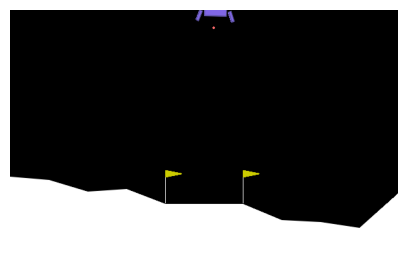

[ 0.05863037  1.4052207   0.20764229 -0.2925947  -0.0381955   0.06985204
  0.          0.        ]


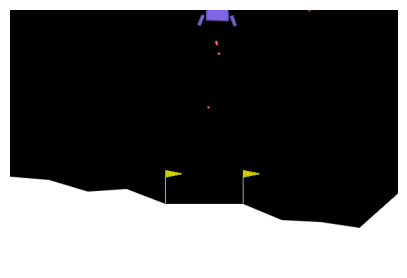

[ 0.06895466  1.3706225   0.19853692 -0.3045801  -0.02251708  0.05567677
  0.          0.        ]


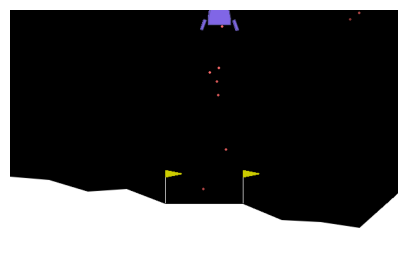

[ 0.07917223  1.3357189   0.18963853 -0.32227308 -0.00839489  0.04417104
  0.          0.        ]


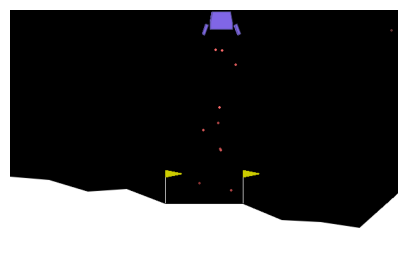

[ 0.08886804  1.3009076   0.1920133  -0.3241517   0.00292166  0.0455128
  0.          0.        ]


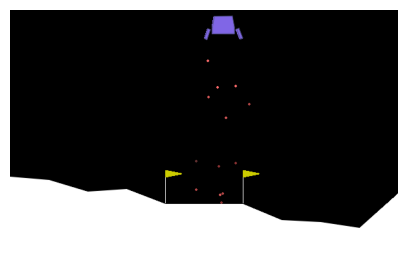

[ 0.09868737  1.2669871   0.19962642 -0.32282242  0.01495258  0.05393802
  0.          0.        ]


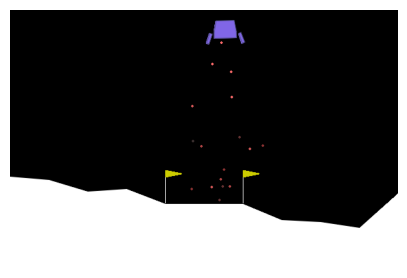

[ 0.10865088  1.2328684   0.20348723 -0.30790994  0.02833162  0.06184574
  0.          0.        ]


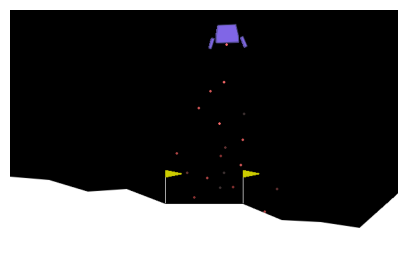

[ 0.1193222   1.1998345   0.2093235  -0.30664504  0.04639481  0.07411765
  0.          0.        ]


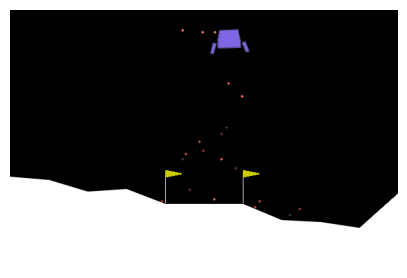

[ 0.12968817  1.1606736   0.22303922 -0.40088755  0.04950266 -0.05316505
  0.          0.        ]


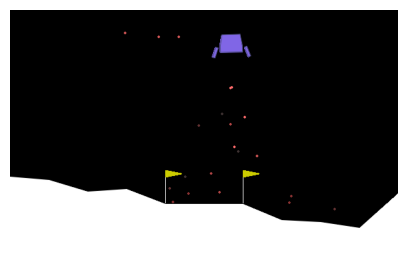

[ 0.1395175   1.1256493   0.19385397 -0.29413292  0.03344841 -0.06569542
  0.          0.        ]


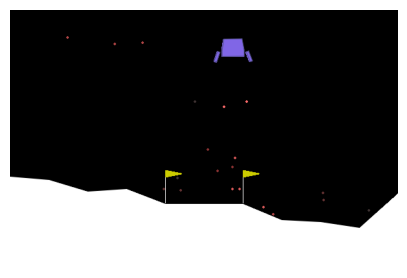

[ 0.14862815  1.0916457   0.1866035  -0.3220366   0.01580443 -0.0684534
  0.          0.        ]


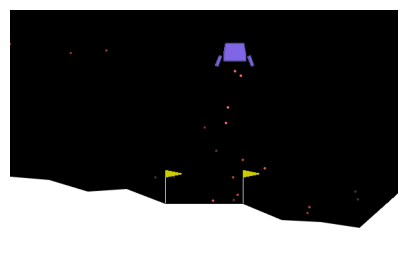

[ 1.5798616e-01  1.0583037e+00  1.7832236e-01 -2.7854815e-01
  7.3502277e-05 -7.3944360e-02  0.0000000e+00  0.0000000e+00]


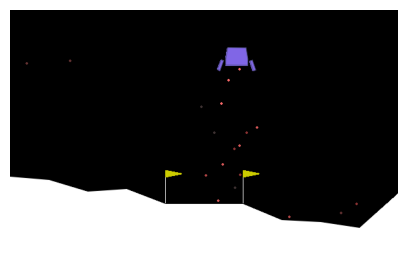

[ 0.16755104  1.0236732   0.19464713 -0.30761066 -0.01465258 -0.05929662
  0.          0.        ]


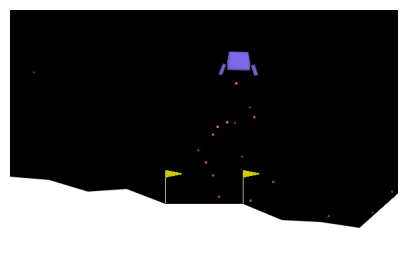

[ 0.17864208  0.99064726  0.23577449 -0.27371582 -0.02305863 -0.02394428
  0.          0.        ]


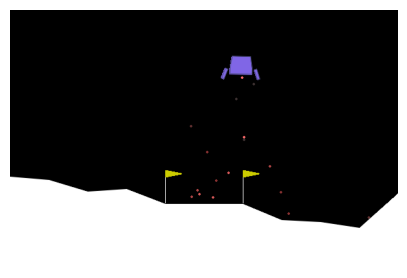

[ 0.19000483  0.95678717  0.21982625 -0.31817707 -0.0311857  -0.0427585
  0.          0.        ]


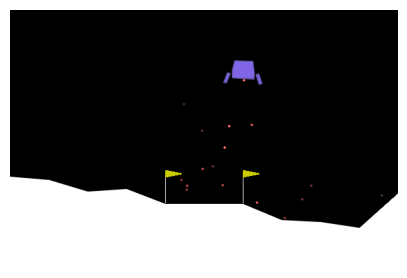

[ 0.20221186  0.92226076  0.24655835 -0.3172838  -0.03678281 -0.02331106
  0.          0.        ]


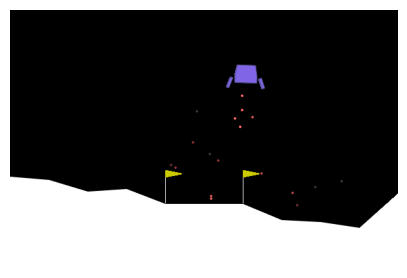

[ 0.21526623  0.88848567  0.27392536 -0.28046364 -0.04025298 -0.00628486
  0.          0.        ]


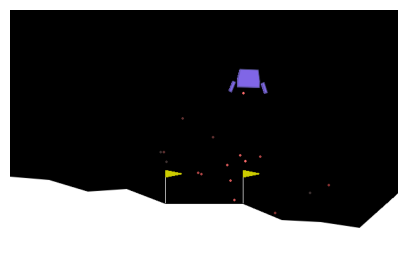

[ 0.22913714  0.8547406   0.29147294 -0.31101656 -0.04179659  0.00460222
  0.          0.        ]


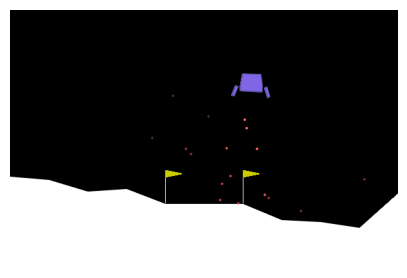

[ 0.24361324  0.8213498   0.2921819  -0.29860118 -0.04251162 -0.00356766
  0.          0.        ]


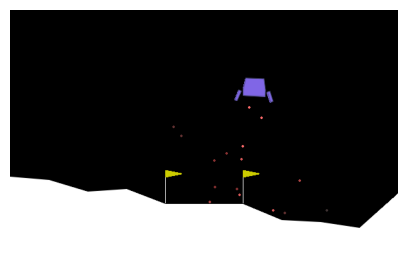

[ 0.25831938  0.78627104  0.31068638 -0.2947157  -0.04391579  0.00568344
  0.          0.        ]


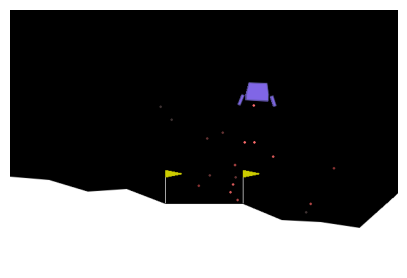

[ 0.27448454  0.75214535  0.3377319  -0.29994223 -0.0407184   0.02389322
  0.          0.        ]


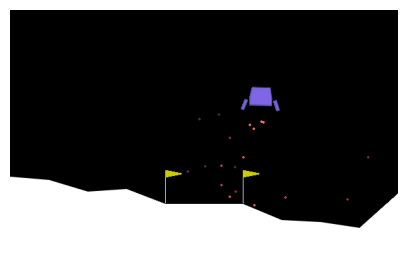

[ 0.29173288  0.716984    0.33711928 -0.272677   -0.0342283   0.01476018
  0.          0.        ]


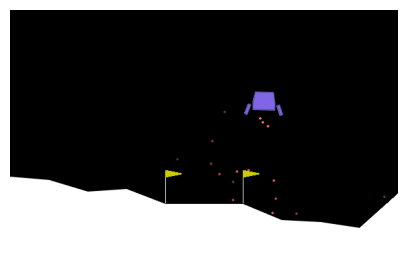

[ 0.30838823  0.6814658   0.33048272 -0.29910654 -0.03205487  0.00328893
  0.          0.        ]


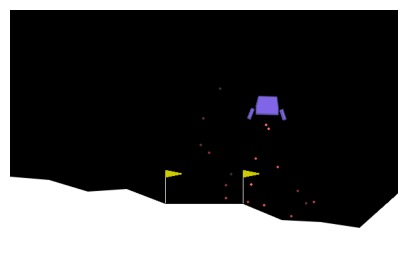

[ 0.32539588  0.64723295  0.3379435  -0.2841915  -0.02984786  0.00387647
  0.          0.        ]


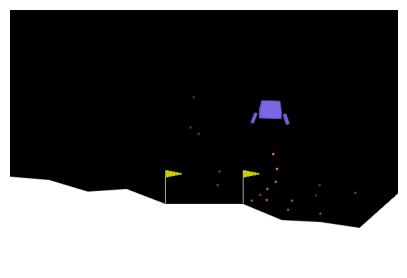

[ 0.3415761   0.6135793   0.31535986 -0.30290163 -0.03291537 -0.02306214
  0.          0.        ]


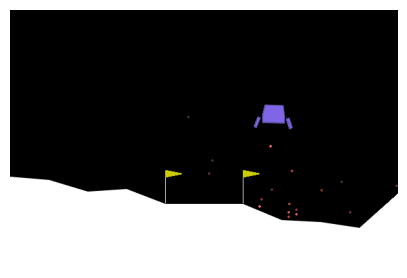

[ 0.35806686  0.5804031   0.3322682  -0.31930113 -0.03608312 -0.01237918
  0.          0.        ]


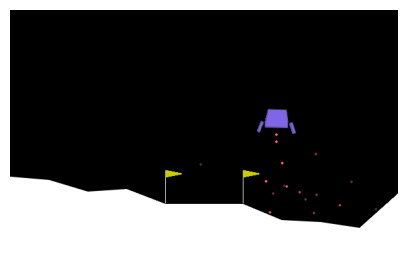

[ 0.37447184  0.54580116  0.3225744  -0.30078685 -0.0411654  -0.03008543
  0.          0.        ]


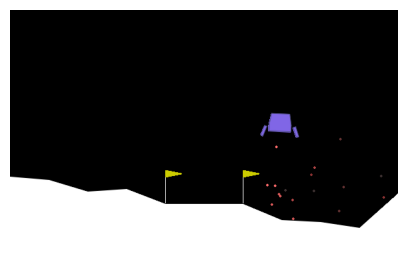

[ 0.39119664  0.5134155   0.34482992 -0.2647573  -0.04695659 -0.01929418
  0.          0.        ]


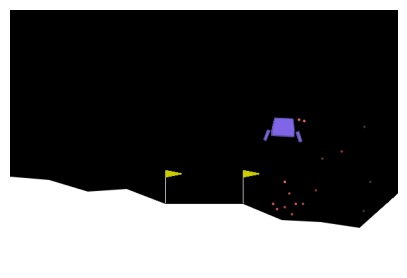

[ 0.40798673  0.4785539   0.3212297  -0.3398699  -0.04814637  0.04080174
  0.          0.        ]


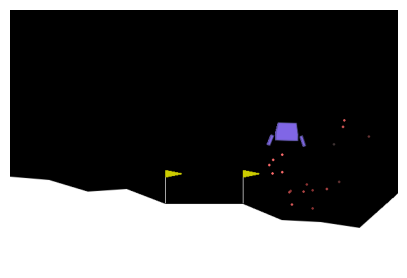

[ 0.42620745  0.44283745  0.38599575 -0.2697739  -0.02996376  0.09173359
  0.          0.        ]


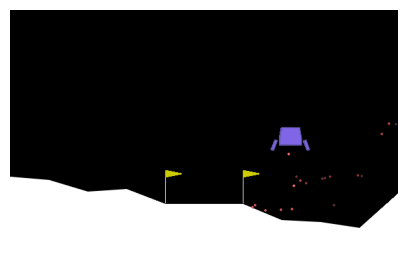

[ 0.44544572  0.40801492  0.3778454  -0.305939   -0.00865372  0.08142452
  0.          0.        ]


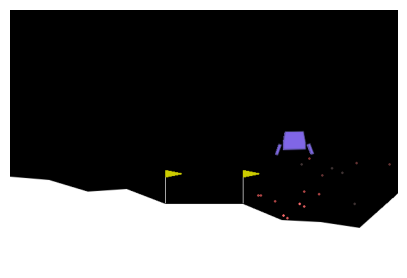

[ 0.46471053  0.37571898  0.37574473 -0.31373736  0.01230524  0.0787095
  0.          0.        ]


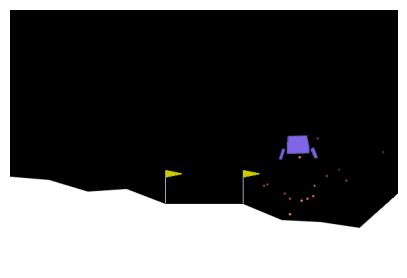

[ 0.48350707  0.34276336  0.35725623 -0.29852107  0.03167526  0.0648886
  0.          0.        ]


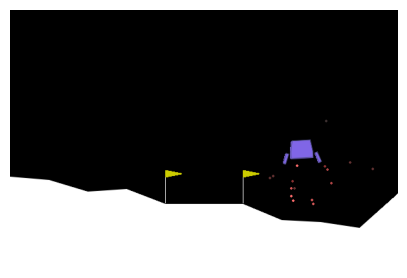

[ 0.5023222   0.30817845  0.38937134 -0.29977396  0.05247612  0.10377438
  0.          0.        ]


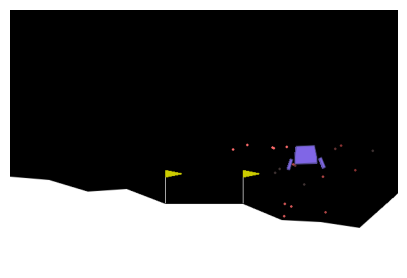

[ 0.5233515   0.2655721   0.44177932 -0.4316924   0.0457348  -0.10641376
  0.          0.        ]


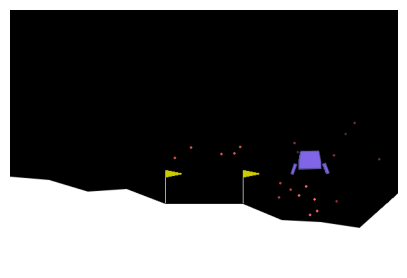

[ 0.54457223  0.22571455  0.43292505 -0.29189697  0.0184657  -0.10145278
  0.          0.        ]


In [7]:
# If you want to look at the values after every 5 actions, use this cell instead
env = gym.make("LunarLander-v3", render_mode="rgb_array")
np.random.seed(42)
obs, info = env.reset(seed=42)
for step in range(200):
    if step%5==0:
        plot_environment(env)
        plt.show()
        print(obs)
    action = basic_policy(obs)
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        break
env.close()

## Modify the CartPole Example

Use the code below (copied from the CartPole example in class) as your starting point.  Recall that the CartPole environment only had 2 actions (push left or push right), whereas our current problem has 4 possible actions (listed above).

1. Modify the neural architecture to output probabilities for each of the 4 possible actions.
2. Change the loss function appropriately (given that we are no longer giving a binary output)
3. Replace the play_one_step function with the following:


```def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape: # Record gradients without applying them
        action_probs = model(obs[np.newaxis]) # Use model policy to determine probability of each action
        action = tf.random.categorical(tf.math.log(action_probs), num_samples=1) # Use probability to decide action
        y_target = tf.one_hot(action, depth=4) # Define target as 1-action
        y_target = tf.reshape(y_target, action_probs.shape) # Match the shape of action_probs for loss computation
        loss = tf.reduce_mean(loss_fn(y_target, action_probs)) # Compute the gradient w.r.t. loss function

    grads = tape.gradient(loss, model.trainable_variables) # Save gradients for trainable variables
    obs, reward, done, truncated, info = env.step(int(action[0,0])) # Record environment state
    return obs, reward, done, truncated, grads # Return relevant information
```


4. Increase the number of simulations per update to 100 and reduce the iterations to 30

In [11]:
n_iterations = 30
n_episodes_per_update = 100
n_max_steps = 200
discount_factor = 0.95
n_actions = 4

#model = tf.keras.Sequential([
#    tf.keras.layers.Dense(5, activation="relu"),
#    tf.keras.layers.Dense(1, activation="sigmoid"),
#])

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"), # Increased units slightly for complexity
    tf.keras.layers.Dense(n_actions, activation="softmax"), # 4 outputs with softmax
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.binary_crossentropy

def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape: # Record gradients without applying them
        action_probs = model(obs[np.newaxis]) # Use model policy to determine probability of each action
        action = tf.random.categorical(tf.math.log(action_probs), num_samples=1) # Use probability to decide action
        y_target = tf.one_hot(action, depth=4) # Define target as 1-action
        y_target = tf.reshape(y_target, action_probs.shape) # Match the shape of action_probs for loss computation
        loss = tf.reduce_mean(loss_fn(y_target, action_probs)) # Compute the gradient w.r.t. loss function

    grads = tape.gradient(loss, model.trainable_variables) # Save gradients for trainable variables
    obs, reward, done, truncated, info = env.step(int(action[0,0])) # Record environment state
    return obs, reward, done, truncated, grads # Return relevant information

def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = play_one_step(
                env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [discount_rewards(rewards, discount_factor)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

In [12]:
def train():
    for iteration in range(n_iterations):
        all_rewards, all_grads = play_multiple_episodes(
            env, n_episodes_per_update, n_max_steps, model, loss_fn)

        # extra code – displays some debug info during training
        total_rewards = sum(map(sum, all_rewards))
        print(f"\rIteration: {iteration + 1}/{n_iterations},"
              f" mean rewards: {total_rewards / n_episodes_per_update:.1f}", end="\n")

        all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                           discount_factor)
        all_mean_grads = []
        for var_index in range(len(model.trainable_variables)):
            mean_grads = tf.reduce_mean(
                [final_reward * all_grads[episode_index][step][var_index]
                 for episode_index, final_rewards in enumerate(all_final_rewards)
                     for step, final_reward in enumerate(final_rewards)], axis=0)
            all_mean_grads.append(mean_grads)

        optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

train()

Iteration: 1/30, mean rewards: -308.3
Iteration: 2/30, mean rewards: -314.0
Iteration: 3/30, mean rewards: -293.8
Iteration: 4/30, mean rewards: -258.6
Iteration: 5/30, mean rewards: -288.3
Iteration: 6/30, mean rewards: -292.2
Iteration: 7/30, mean rewards: -259.8
Iteration: 8/30, mean rewards: -230.9
Iteration: 9/30, mean rewards: -238.6
Iteration: 10/30, mean rewards: -204.6
Iteration: 11/30, mean rewards: -199.2
Iteration: 12/30, mean rewards: -215.1
Iteration: 13/30, mean rewards: -225.1
Iteration: 14/30, mean rewards: -203.1
Iteration: 15/30, mean rewards: -193.0
Iteration: 16/30, mean rewards: -180.1
Iteration: 17/30, mean rewards: -176.4
Iteration: 18/30, mean rewards: -177.1
Iteration: 19/30, mean rewards: -174.9
Iteration: 20/30, mean rewards: -177.9
Iteration: 21/30, mean rewards: -166.1
Iteration: 22/30, mean rewards: -163.7
Iteration: 23/30, mean rewards: -156.3
Iteration: 24/30, mean rewards: -164.1
Iteration: 25/30, mean rewards: -157.3
Iteration: 26/30, mean rewards: -1

In [14]:
# extra code – displays the animation
def pg_policy(obs):
    action_probs = model.predict(obs[np.newaxis], verbose=0)
    action = tf.random.categorical(tf.math.log(action_probs), num_samples=1) # Use probability to decide action
    return int(action[0,0])

show_one_episode(pg_policy)

### Comment on the performance

In [15]:
# I believe that the new CartPole is capable of making the 4 actions as requested: it can move left/right, but it is also capable of rotating
# and moving down.  But as displayed in the animation above, the new performance is worse than the previous CartPole: the CartPole has not landed
# in the safe zone between the yellow flags, and it has not landed properly.  That said, the mean total score yields very negative results.

### Modify the architecture of the neural model to allow the model to learn more complex behavior
#### Try a different number of layers and neurons per layer

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)

train()

In [ ]:
# extra code – displays the animation
def pg_policy(obs):
    action_probs = model.predict(obs[np.newaxis], verbose=0)
    action = tf.random.categorical(tf.math.log(action_probs), num_samples=1) # Use probability to decide action
    return int(action[0,0])

show_one_episode(pg_policy)

### Your model likely learned to hover near the top of the viewing window.  Modify the play_multiple_episodes function to encourage the model to hover closer to the landing pad by changing its rewards.  Specifically, add 5 points to the score when the lander is within 0.5 of the ground (y-value only).

In [ ]:
def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = play_one_step(
                env, obs, model, loss_fn)
            # Modify the rewards



            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

In [ ]:
old_model = model
model = tf.keras.models.clone_model(old_model)
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)


train()

show_one_episode(pg_policy)

### Before submission, save the weights of your final model and submit along with this notebook.

In [ ]:
model.save_weights('model_weights.h5')